# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import tigramite.plotting as tp
from tigramite.independence_tests.parcorr import ParCorr


from utils import load_ts_df

# Data

In [2]:
lamah_ce_path = Path("/home/tripleuuu/Nextcloud/coding/causal_inference/snow_causal_inference/data/raw_data/2_LamaH-CE_daily")

climate_ts_802_path = lamah_ce_path / "B_basins_intermediate_all/2_timeseries/daily/ID_802.csv"
q_ts_802_path = lamah_ce_path / "D_gauges/2_timeseries/daily/ID_802.csv"

In [3]:
climate_ts_802_df = load_ts_df(climate_ts_802_path) 
q_ts_802_df = load_ts_df(q_ts_802_path) 

In [4]:
climate_ts_802_df.columns

Index(['DOY', '2m_temp_max', '2m_temp_mean', '2m_temp_min', '2m_dp_temp_max',
       '2m_dp_temp_mean', '2m_dp_temp_min', '10m_wind_u', '10m_wind_v',
       'fcst_alb', 'lai_high_veg', 'lai_low_veg', 'swe',
       'surf_net_solar_rad_max', 'surf_net_solar_rad_mean',
       'surf_net_therm_rad_max', 'surf_net_therm_rad_mean', 'surf_press',
       'total_et', 'prec', 'volsw_123', 'volsw_4'],
      dtype='str')

# 1. Graph-Validation 

Check that the distribution is markov to the graph. 

In [5]:
# Just pick the variables in the graph (climate + discharge)
climate_vars_df = climate_ts_802_df.loc[:, ["2m_temp_mean", "prec", "total_et", "volsw_123", "swe"]]
vars_df = pd.concat([climate_vars_df, q_ts_802_df["qobs"]], axis=1)

In [6]:
# define tigramite graph and plot it 

N = len(vars_df.columns)
tau_max = 1

graph = np.zeros((N, N, tau_max + 1), dtype="<U3")
graph[:] = "" 


# temp 
graph[0, 0, 1] = "-->" # self causation
graph[0, 1, 1] = "-->" # lagged on prec (reseach for alps)
graph[0, 2, 1] = "-->" # lagged on et (set to lag, as et instantenous impacts temp instantly (it rains, it gets colder)) 
graph[0, 3, 0] = "-->" # impact on sm
graph[3, 0, 0] = "<--" # reverse
graph[0, 4, 0] = "-->" # impact on swe
graph[4, 0, 0] = "<--" # reverse

# prec 
graph[1, 1, 1] = "-->" # self causation
graph[1, 2, 0] = "-->" # impact on et
graph[2, 1, 0] = "<--" # reverse
graph[1, 3, 0] = "-->" # impact on sm
graph[3, 1, 0] = "<--" # reverse
graph[1, 4, 0] = "-->" # impact on swe
graph[4, 1, 0] = "<--" # reverse
graph[1, 5, 0] = "-->" # impact on q
graph[5, 1, 0] = "<--" # reverse

# et 
graph[2, 2, 1] = "-->" # self causation
graph[2, 1, 0] = "-->" # impact on 
graph[2, 1, 0] = "<--" # reverse
graph[2, 3, 1] = "-->" # impact on sm
graph[3, 2, 1] = "<--" # reverse
graph[2, 3, 0] = "-->" # impact on sm
graph[3, 2, 0] = "<--" # reverse

# sm  
graph[3, 3, 1] = "-->" # self causation

# swe 
graph[4, 4, 1] = "-->" # self causation

# q
graph[5, 5, 1] = "-->" # self causation


(<Figure size 640x480 with 1 Axes>, <Axes: >)

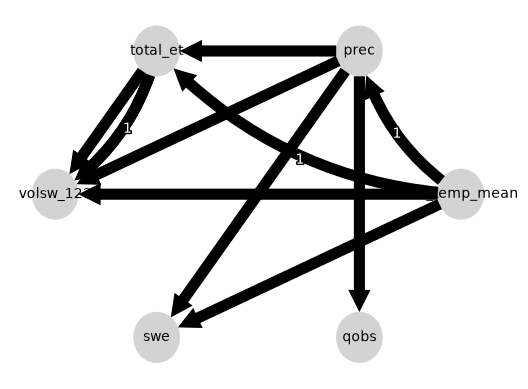

In [7]:
tp.plot_graph(
    graph=graph,
    var_names=vars_df.columns
)

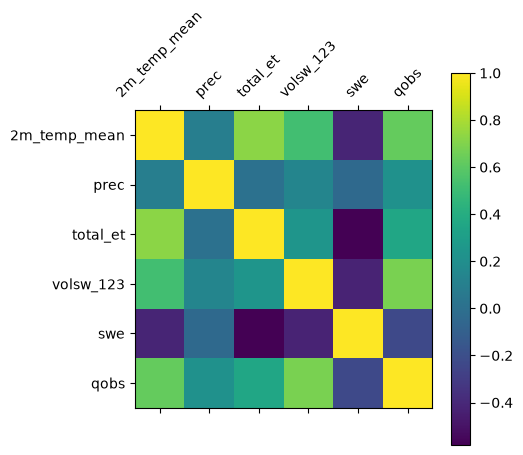

In [8]:
corr_mat = vars_df.corr()

plt.matshow(corr_mat)
plt.yticks(ticks=range(len(corr_mat)), labels=vars_df.columns)
plt.xticks(ticks=range(len(corr_mat)), labels=vars_df.columns, rotation=45)
plt.colorbar()

In [9]:
parcorr_obj = ParCorr()

parcorr_obj.run_test()

TypeError: CondIndTest.run_test() missing 2 required positional arguments: 'X' and 'Y'